In [1]:
import numpy as np
import pandas as pd
import re

VALUE_COL = 'avg_saliency'   
EXCLUDE_AREAS = ['Medial_wall', 'Cerebral Cortex', 'Inferior Lateral Ventricle', 'Lateral Ventricle']

saliency = pd.read_csv('/projectnb/nickar/sidd/mednet/permtest/ig_correct_fold/avg_ig_by_region.csv')
lookup = pd.read_csv('/projectnb/nickar/sidd/fs_lookup.csv', usecols=['code', 'region'])
lobe_info = pd.read_csv('/projectnb/nickar/sidd/destrieux - lobe.csv')

merged = pd.merge(saliency, lookup, left_on='region_id', right_on='code', how='left')
merged = merged.dropna(subset=['region'])
merged = merged[~merged['region'].str.contains('Unknown', case=False)]
merged['hemi'] = merged['region'].str.extract(r'ctx_(lh|rh)_')
merged['area'] = merged['region'].str.replace(r'^ctx_(lh|rh)_', '', regex=True)
merged['severity'] = merged['true_label'].map({1: 'high', 0: 'low'})
merged = merged[~merged['area'].isin(EXCLUDE_AREAS)]
merged = merged.dropna(subset=['hemi', 'severity'])

stats = merged.groupby(['area', 'hemi', 'severity'], observed=True)[VALUE_COL].agg(['mean', 'std'])
wide = stats.unstack(['hemi', 'severity'])
wide.columns = [f'{h}_{s}_{stat}' for stat, h, s in wide.columns]

lobe_of = dict(zip(lobe_info['area'], lobe_info['lobe']))
keep = [a for a in lobe_info['area'] if a in wide.index]
missing = [a for a in lobe_info['area'] if a not in wide.index]
if missing:
    print(f'{len(missing)} regions in the lobe CSV absent from the saliency table:', missing)
wide = wide.loc[keep]

area = list(wide.index)
lobe = [lobe_of[a] for a in area]

lh_high_avg = wide['lh_high_mean'].to_numpy()
lh_low_avg  = wide['lh_low_mean'].to_numpy()
rh_high_avg = wide['rh_high_mean'].to_numpy()
rh_low_avg  = wide['rh_low_mean'].to_numpy()
lh_high_std = wide['lh_high_std'].to_numpy()
lh_low_std  = wide['lh_low_std'].to_numpy()
rh_high_std = wide['rh_high_std'].to_numpy()
rh_low_std  = wide['rh_low_std'].to_numpy()

print(f'{len(area)} regions, {len(set(lobe))} lobes: {sorted(set(lobe))}')

1 regions in the lobe CSV absent from the saliency table: ['Medial_wall']
74 regions, 5 lobes: ['frontal', 'limbic', 'occipital', 'parietal', 'temporal']


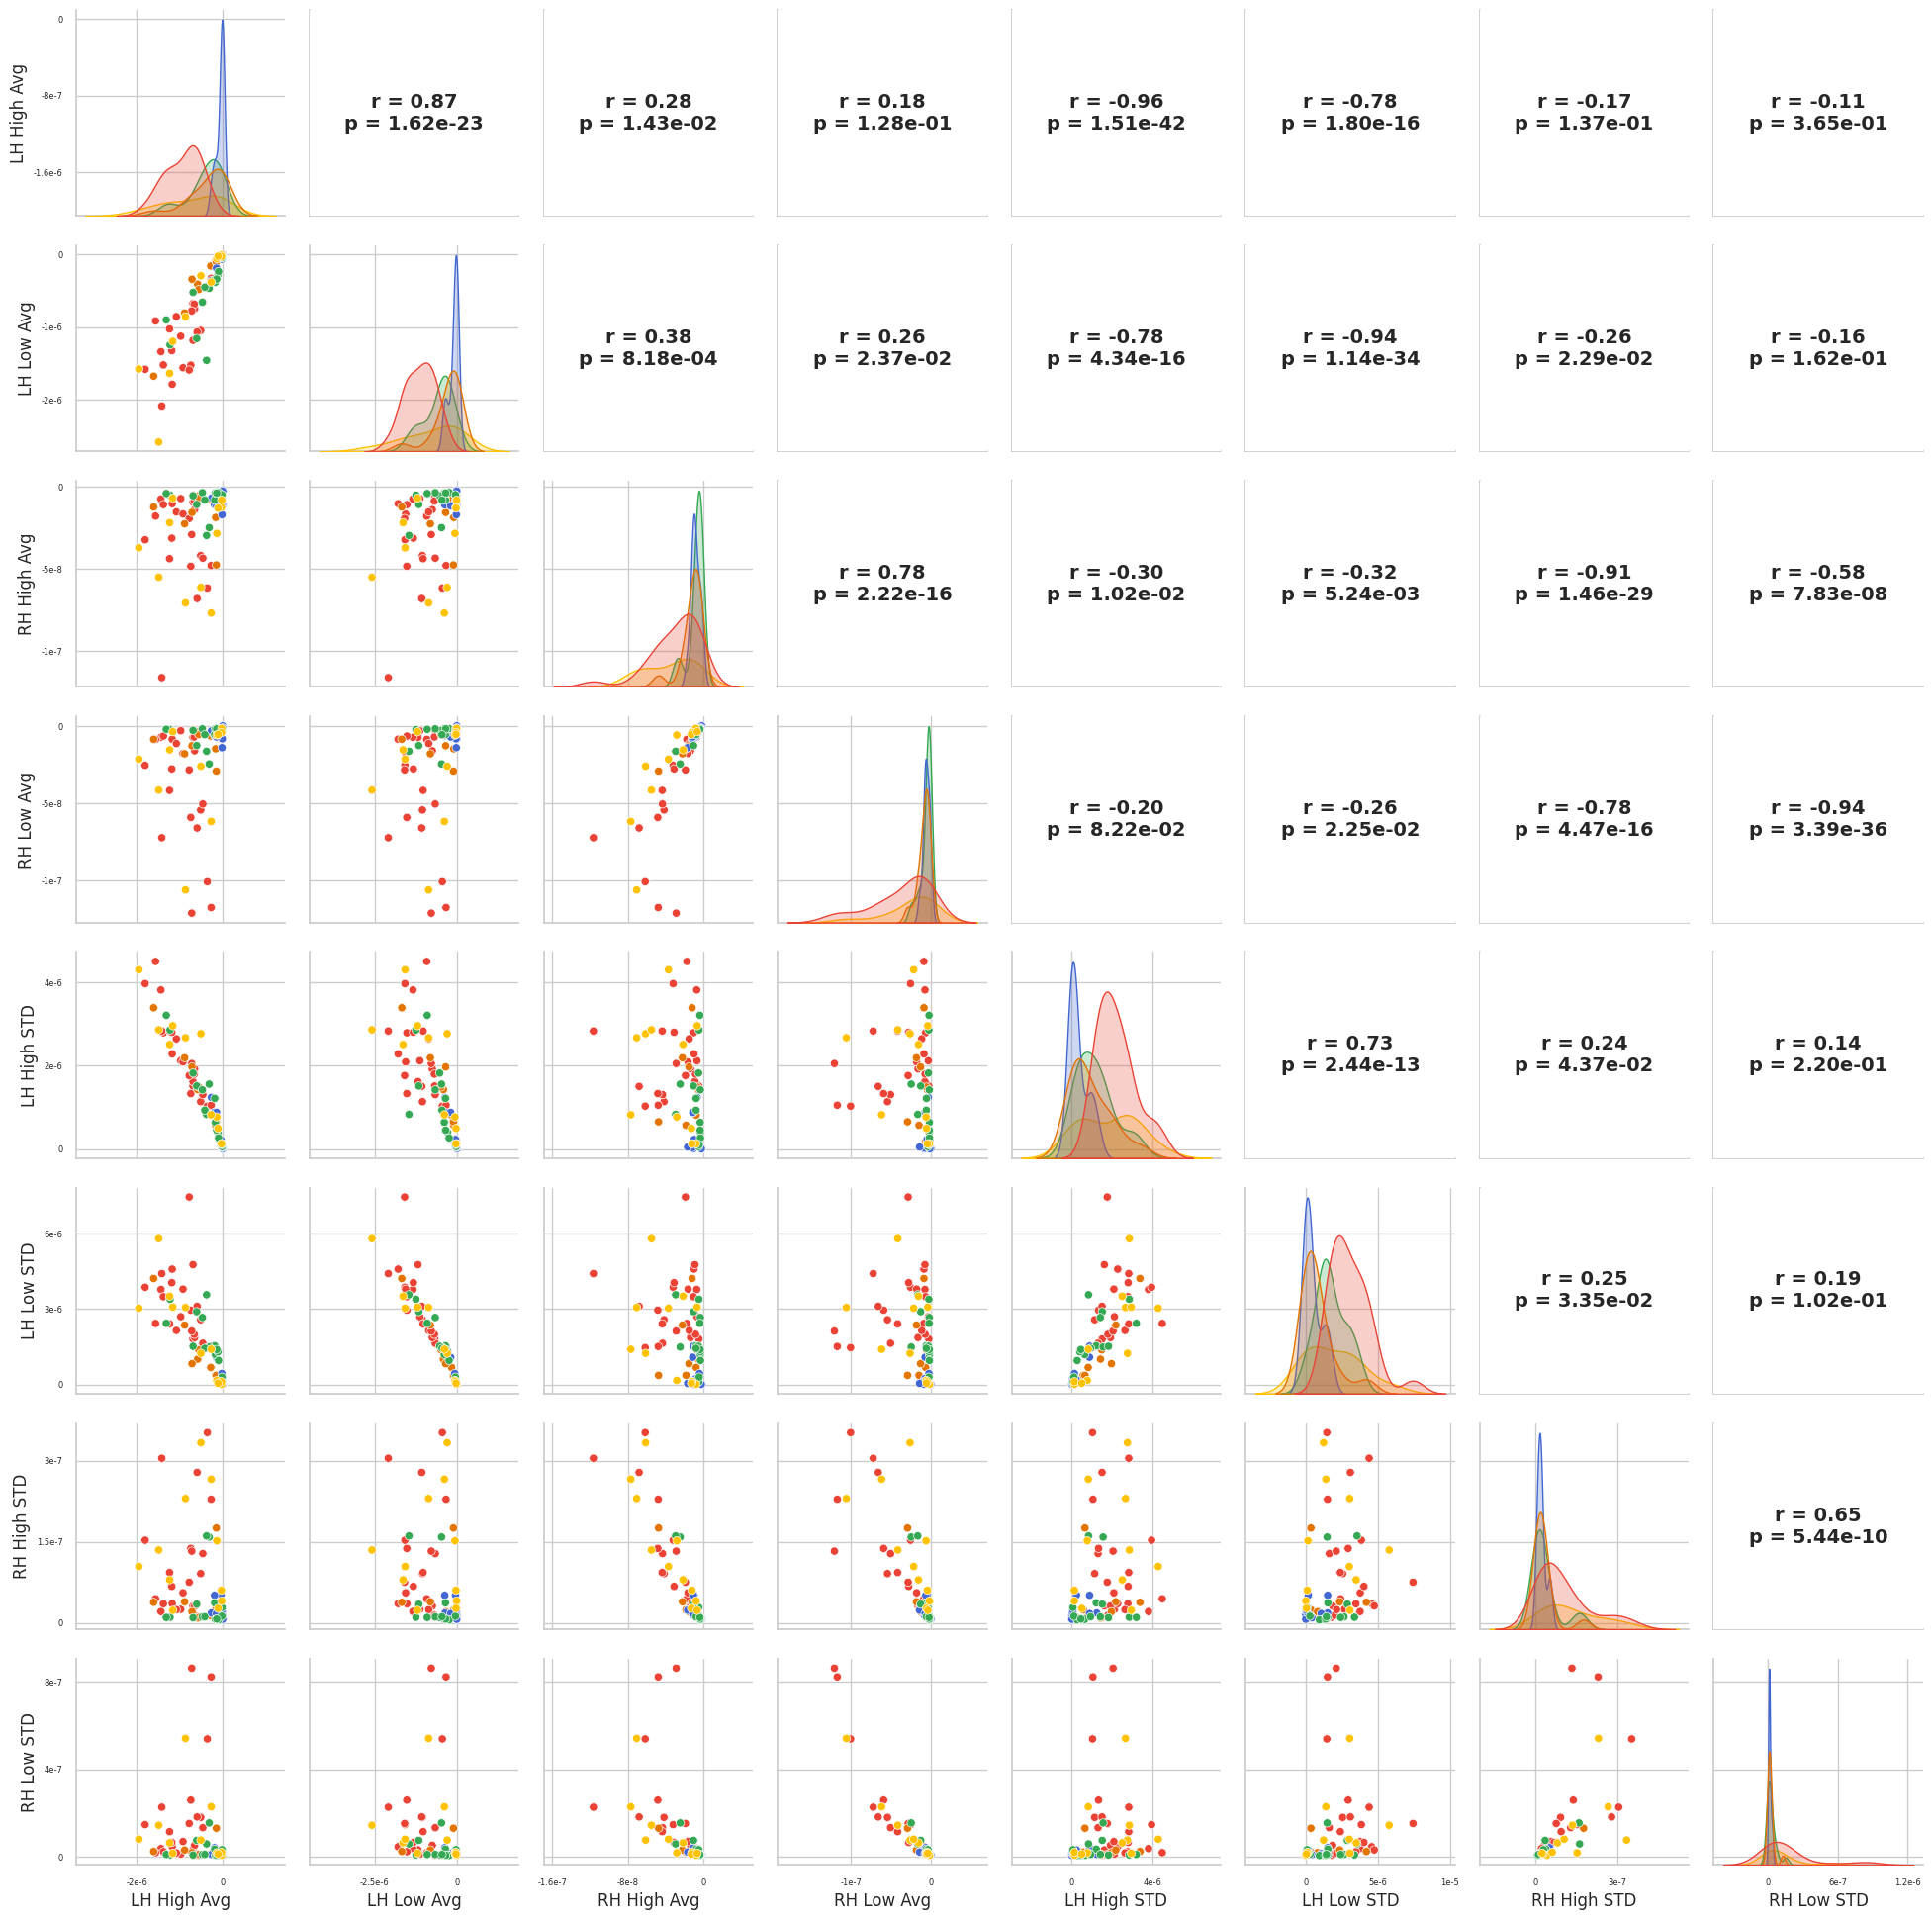

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sns.set_theme(style='whitegrid')

def get_rgba_value(number):
    if number == 'frontal':
        return (234/255,67/255,53/255, 255/255)
    elif number == 'parietal':
        return (227/255,116/255,0/255, 255/255)
    elif number == 'occipital':
        return (66/255,103/255,210/255, 255/255)
    elif number == 'temporal':
        return (52/255,168/255,83/255, 255/255)
    elif number == 'limbic':
        return (255/255,194/255,0/255, 255/255)
    elif number == 5:
        return (251/255,188/255,4/255,255/255)

data = pd.DataFrame({
'LH High Avg': lh_high_avg,
'LH Low Avg': lh_low_avg,
'RH High Avg': rh_high_avg,
'RH Low Avg': rh_low_avg,
'LH High STD': lh_high_std,
'LH Low STD': lh_low_std,
'RH High STD': rh_high_std,
'RH Low STD': rh_low_std,
'Lobe': lobe
})

unique_lobes = sorted(list(set(lobe)))
custom_colors = [get_rgba_value(lobe_val) for lobe_val in unique_lobes]
palette_dict = dict(zip(unique_lobes, custom_colors))

g = sns.pairplot(data, hue='Lobe', palette=palette_dict, corner=False, aspect=1)

vars_list = [col for col in data.columns if col != 'Lobe']

for i in range(len(vars_list)):
    for j in range(len(vars_list)):
        if i < j:  
            ax = plt.subplot2grid((len(vars_list), len(vars_list)), (i, j))
            x_data = data[vars_list[j]]
            y_data = data[vars_list[i]]
            r, p = pearsonr(x_data, y_data)
            ax.text(0.5, 0.5, f"r = {r:.2f}\np = {p:.2e}",
                   transform=ax.transAxes,
                   ha='center', va='center',
                   fontsize=14, fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
g._legend.remove()

from matplotlib.ticker import FuncFormatter, MaxNLocator
from math import log10, floor

def sigfig_fmt(x, pos, sig=2):
    if x == 0:
        return '0'
    exp = floor(log10(abs(x)))
    mantissa = x / (10 ** exp)
    mantissa = round(mantissa, sig - 1)
    if abs(mantissa) >= 10:
        mantissa /= 10
        exp += 1
    m_str = f'{mantissa:.{max(sig-1,0)}f}'.rstrip('0').rstrip('.')
    return f'{m_str}e{exp}' if exp != 0 else m_str

for ax in g.axes.flat:
    if ax is None:
        continue
    ax.xaxis.set_major_formatter(FuncFormatter(sigfig_fmt))
    ax.yaxis.set_major_formatter(FuncFormatter(sigfig_fmt))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))   
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.tick_params(labelsize=6)

plt.show()